In [1]:
import pandas as pd
import torch
from torchtext import data
from torchtext.data import BucketIterator
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import random
from gensim.models import Word2Vec
import torchtext
import matplotlib.pyplot as plt
from torchtext.data import Field, LabelField
from torchtext.data import BucketIterator
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc
from nltk.tokenize import word_tokenize
import re
import nltk
nltk.download('punkt')


# Проверка доступности GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
# Загрузка датасета
df = pd.read_csv('FakeNewsNet.csv')  # Замените на путь к вашему файлу
df = df[['title', 'news_url', 'source_domain', 'real']]

# Проверка на null-значения
print(df.isnull().sum())
df.dropna(inplace=True)

# Проверка баланса классов
print(df['real'].value_counts())

# Комбинирование текстов
df['text'] = df['title'] + ' ' + df['news_url'] + ' ' + df['source_domain']
df = df[['text', 'real']]

title              0
news_url         330
source_domain    330
real               0
dtype: int64
real
1    17371
0     5495
Name: count, dtype: int64


In [3]:
# Определите поля (fields)
TEXT = data.Field(sequential=True, tokenize='spacy', lower=True, tokenizer_language='en_core_web_sm')
LABEL = data.LabelField(dtype=torch.float)

# Создайте список примеров
examples = []
for index, row in df.iterrows():
    text = row['text']
    label = row['real']
    examples.append(data.Example.fromlist([text, label], fields=[('text', TEXT), ('label', LABEL)]))

# Создайте Dataset
dataset = data.Dataset(examples, fields=[('text', TEXT), ('label', LABEL)])

In [4]:
# Задайте seed для воспроизводимости
SEED = 42
random.seed(SEED)

# Разбейте на тренировочный и тестовый наборы данных
train_data, test_data = dataset.split(split_ratio=0.8, random_state=random.seed(SEED))

# Построение словаря
TEXT.build_vocab(train_data)
LABEL.build_vocab(train_data)

# Определение BATCH_SIZE 
BATCH_SIZE = 30


# Создаём итератор
train_iterator, test_iterator = BucketIterator.splits(
    (train_data, test_data),
    batch_size=BATCH_SIZE,
    device=device,
    sort_within_batch=True,
    sort_key=lambda x: len(x.text))

In [5]:
class RNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(RNN, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(pre_trained_emb, padding_idx=0)
        self.rnn = nn.RNN(embedding_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

        
    def forward(self, text):
        embedded = self.embedding(text)
        output, hidden = self.rnn(embedded)
        output = self.fc(hidden[-1])
        return output.squeeze()

In [6]:
# Обучение модели LSTM
class LSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(LSTM, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(pre_trained_emb, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)


    def forward(self, text):
        embedded = self.embedding(text)
        output, hidden = self.lstm(embedded)
        output = self.fc(hidden[-1])
        return output.squeeze()

In [7]:
# Обучение модели GRU
class GRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(GRU, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(pre_trained_emb, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)


    def forward(self, text):
        embedded = self.embedding(text)
        output, hidden = self.gru(embedded)
        output = self.fc(hidden[-1])
        return output.squeeze()

In [ ]:
def collate_fn(batch):
    text, label = zip(*batch)
    text = [torch.tensor(t, dtype=torch.long) for t in text]  # Используем torch.tensor
    text = pad_sequence(text, batch_first=True, padding_value=0)
    label = torch.tensor(label, dtype=torch.float)  # Используем torch.tensor
    return text.to(device), label.to(device)

# Определяем модель
class AttentionModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.LSTM(embedding_dim, hidden_dim, n_layers, dropout = dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        output, (hidden, cell) = self.rnn(embedded)
        hidden = self.dropout(hidden[-1,:,:])
        return self.fc(hidden.squeeze(0))

In [8]:
# Определяем параметры модели
INPUT_DIM = len(TEXT.vocab)
EMBEDDING_DIM = 100
HIDDEN_DIM = 64
OUTPUT_DIM = 1
N_LAYERS = 1


In [9]:
# Обучение модели Word2Vec
sentences = [TEXT.tokenize(' '.join(example.text)) for example in train_data]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=5, workers=4)
w2v_model.save('word2vec.txt')

# Загружаем обученную модель Word2Vec
w2v_model = Word2Vec.load('word2vec.txt')

# Извлекаем векторы слов из модели Word2Vec
word2vec_vectors = torch.FloatTensor(w2v_model.wv.vectors)

# Создаем Embedding слой с предобученными векторами
pre_trained_emb = word2vec_vectors

In [10]:
# Обучение и оценка модели
def train_and_evaluate(model_class, epochs):
    model = model_class(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)
    optimizer = optim.Adam(model.parameters())
    criterion = nn.BCEWithLogitsLoss()
    train_losses = []
    test_losses = []

    for epoch in tqdm(range(epochs), desc='Epochs'):
        train_loss = train(model, train_iterator, optimizer, criterion)
        test_loss = evaluate(model, test_iterator, criterion)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        print(f'Epoch: {epoch+1:02}, Train Loss: {train_loss:.3f}, Test Loss: {test_loss:.3f}')

    # Оценка работы модели
    predictions, labels = predict(model, test_iterator)

    # Метрики
    accuracy = accuracy_score(labels, (np.array(predictions) > 0.5).astype(int))
    f1 = f1_score(labels, (np.array(predictions) > 0.5).astype(int))
    roc_auc = roc_auc_score(labels, predictions)

    print(f'Accuracy: {accuracy:.3f}')
    print(f'F1 Score: {f1:.3f}')
    print(f'ROC AUC Score: {roc_auc:.3f}')

    # Графики
    plt.plot(train_losses, label='Training Loss')
    plt.plot(test_losses, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # График ROC AUC
    fpr, tpr, _ = roc_curve(labels, predictions)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

In [11]:
def train(model, iterator, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in tqdm(iterator, desc='Training'):
        text, label = batch
        optimizer.zero_grad()
        output = model(text)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(iterator)

def evaluate(model, iterator, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(iterator, desc='Evaluating'):
            text, label = batch
            output = model(text)
            loss = criterion(output, label)
            total_loss += loss.item()
    return total_loss / len(iterator)


In [12]:
def predict(model, iterator):
    model.eval()
    predictions = []
    labels = []
    with torch.no_grad():
        for batch in tqdm(iterator, desc='Predicting'):
            text, label = batch
            output = model(text)
            predictions.extend(output.sigmoid().flatten().tolist())
            labels.extend(label.tolist())
    return predictions, labels

In [13]:
N_EPOCHS = 19

# Обучение и оценка всех моделей
print('Обучение и оценка модели RNN:')
train_and_evaluate(RNN, N_EPOCHS)
print('Обучение и оценка модели LSTM:')
train_and_evaluate(LSTM, N_EPOCHS)
print('Обучение и оценка модели GRU:')
train_and_evaluate(GRU, N_EPOCHS)

Обучение и оценка модели RNN:


Epochs:   0%|          | 0/19 [00:00<?, ?it/s]


RuntimeError: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR_HOST_ALLOCATION_FAILED

In [16]:
model = AttentionModel(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT)

# Определяем оптимизатор и функцию потерь
optimizer = optim.Adam(model.parameters())
criterion = nn.BCEWithLogitsLoss()

model = model.to(device)
criterion = criterion.to(device)

C:\Users\User\AppData\Roaming\Python\Python310\site-packages\torch\nn\modules\rnn.py:88: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


In [17]:
# Вычисляем accuracy
def binary_accuracy(preds, y):
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc

def train(model, iterator, optimizer, criterion):
    epoch_loss = 0
    epoch_acc = 0
    model.train()

    all_predictions = []
    all_labels = []

    for batch in iterator:
        optimizer.zero_grad()
        predictions = model(batch.text).squeeze(1)
        loss = criterion(predictions, batch.label)
        acc = binary_accuracy(predictions, batch.label)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

        all_predictions += predictions.tolist()
        all_labels += batch.label.tolist()

    all_predictions = torch.tensor(all_predictions)
    all_labels = torch.tensor(all_labels)
    val_acc = binary_accuracy(all_predictions, all_labels)
    val_loss = criterion(all_predictions, all_labels).item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator), val_loss, val_acc.item()

In [35]:
N_EPOCHS = 19

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in tqdm(range(N_EPOCHS)):
    train_loss, train_acc, val_loss, val_acc = train(model, train_iterator, optimizer, criterion)
    print(f'Epoch: {epoch+1:02}, Train Loss: {train_loss:.3f}, Train Acc: {train_acc*100:.2f}%, Val Loss: {val_loss:.3f}, Val Acc: {val_acc*100:.2f}%')

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

  5%|▌         | 1/19 [00:03<00:58,  3.25s/it]

Epoch: 01, Train Loss: 0.006, Train Acc: 99.84%, Val Loss: 0.006, Val Acc: 99.84%


 11%|█         | 2/19 [00:06<00:55,  3.24s/it]

Epoch: 02, Train Loss: 0.006, Train Acc: 99.82%, Val Loss: 0.006, Val Acc: 99.82%


 16%|█▌        | 3/19 [00:09<00:51,  3.24s/it]

...

Epoch: 17, Train Loss: 0.003, Train Acc: 99.93%, Val Loss: 0.003, Val Acc: 99.93%


 95%|█████████▍| 18/19 [00:58<00:03,  3.25s/it]

Epoch: 18, Train Loss: 0.003, Train Acc: 99.92%, Val Loss: 0.003, Val Acc: 99.92%


100%|██████████| 19/19 [01:01<00:00,  3.25s/it]

Epoch: 19, Train Loss: 0.003, Train Acc: 99.92%, Val Loss: 0.003, Val Acc: 99.92%


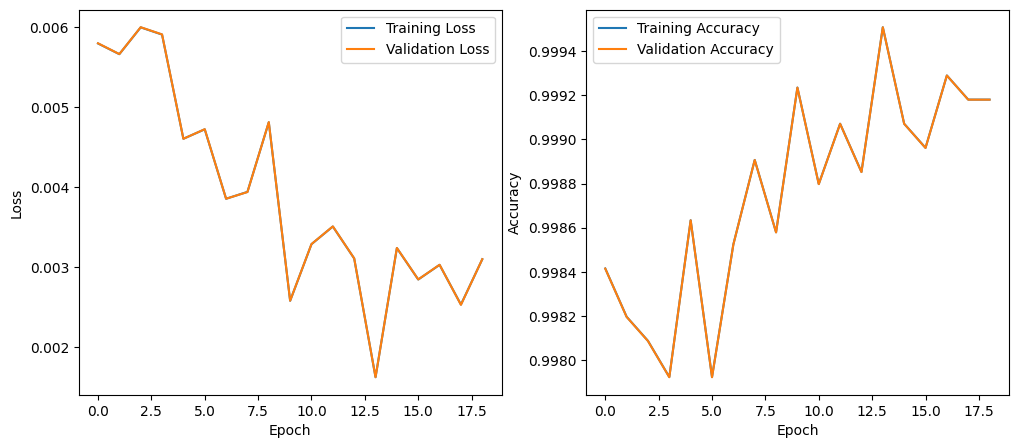

In [36]:
plt.figure(figsize=(12, 5))

#Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

#Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [37]:
# Сохранение модели
torch.save(model.state_dict(), 'model_pytorchw2w.pt' )

100%|██████████| 153/153 [00:00<00:00, 427.38it/s]


Accuracy: 0.8569866608353378
F1 Score: 0.6491416309012875
ROC AUC Score: 0.8488148811534711


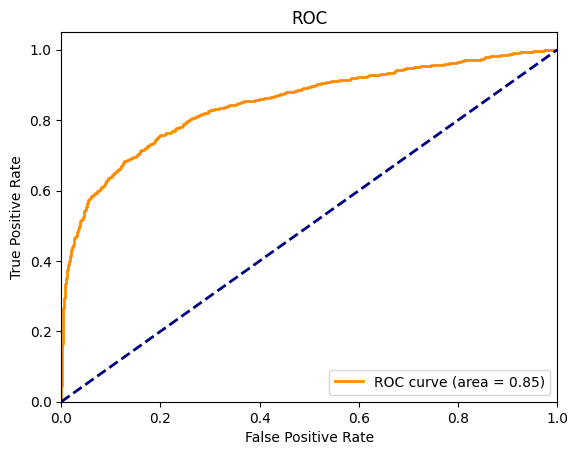

In [38]:
def evaluate_model(model, iterator):
    all_predictions = []
    all_labels = []

    for batch in tqdm(iterator):
        predictions = model(batch.text).squeeze(1)
        all_predictions += predictions.tolist()
        all_labels += batch.label.tolist()

    all_predictions = torch.tensor(all_predictions)
    all_labels = torch.tensor(all_labels)

    y_pred_binary = torch.round(torch.sigmoid(all_predictions)).cpu().numpy()
    y_true = all_labels.cpu().numpy()

    accuracy = accuracy_score(y_true, y_pred_binary)
    f1 = f1_score(y_true, y_pred_binary)
    roc_auc = roc_auc_score(y_true, all_predictions.cpu().numpy())

    print("Accuracy:", accuracy)
    print("F1 Score:", f1)
    print("ROC AUC Score:", roc_auc)

    fpr, tpr, _ = roc_curve(y_true, all_predictions.cpu().numpy())
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC')
    plt.legend(loc="lower right")
    plt.show()

evaluate_model(model, test_iterator)